# 04 EDA - Player Engagement

## Goal

The goal of this notebook is to explore the player-level engagement dataset and identify initial patterns related to churn, activity duration, game ownership, achievements and social connections.

## Load Libraries


In [45]:
import os
from idlelib import query
from unittest import result

import pandas as pd
from pathlib import Path
from dotenv import load_dotenv
from sqlalchemy import create_engine, inspect, text
import matplotlib.pyplot as plt

## Connect to PostgreSQL


In [38]:
PROJECT_ROOT = Path("..")
PROCESSED_DATA_PATH = PROJECT_ROOT / "Data" / "processed"
FIGURES_PATH = Path("../reports/figures")

load_dotenv(PROJECT_ROOT / ".env")

DB_HOST = os.getenv("DB_HOST")
DB_PORT = os.getenv("DB_PORT")
DB_NAME = os.getenv("DB_NAME")
DB_USER = os.getenv("DB_USER")
DB_PASSWORD = os.getenv("DB_PASSWORD")
DB_SCHEMA = os.getenv("DB_SCHEMA", "steam")

In [3]:
connection_string =(
    f"postgresql+psycopg2://{DB_USER}:{DB_PASSWORD}"
    f"@{DB_HOST}:{DB_PORT}/{DB_NAME}"
)
engine = create_engine(connection_string)

## Load Analytical Dataset


In [14]:
query = """
SELECT
    *
FROM steam.mv_player_engagement_base
"""

mv_player_engagement_base = pd.read_sql(query, engine)

mv_player_engagement_base.head()

df = pd.DataFrame(mv_player_engagement_base)

## Dataset Overview


In [15]:
df.head()

,player_id,country,account_created_date,first_activity_date,last_activity_date,active_days,total_achievements_unlocked,games_with_activity,games_owned,friend_count,dataset_end_date,churn_cutoff_date,churned
0,76561197960278782,Belgium,2003-09-12 13:03:57,2020-04-13 08:47:47,2021-02-12 18:52:13,305,760,12,235,211,2025-01-08 06:13:16,2024-07-12 06:13:16,1
1,76561197960288251,Belgium,2003-09-12 14:14:22,2009-06-11 22:24:02,2024-06-28 22:17:25,5495,983,74,234,0,2025-01-08 06:13:16,2024-07-12 06:13:16,1
2,76561197960315163,NaN,2003-09-12 16:31:42,2009-09-20 23:27:55,2024-12-11 02:17:04,5560,1427,124,1794,0,2025-01-08 06:13:16,2024-07-12 06:13:16,0
3,76561197960321434,United Kingdom,2003-09-12 17:01:44,2009-06-13 03:06:10,2024-11-30 20:33:37,5649,939,68,301,28,2025-01-08 06:13:16,2024-07-12 06:13:16,0
4,76561197960328391,France,2003-09-12 17:30:26,2012-11-21 22:26:03,2023-12-21 23:19:40,4047,295,40,142,75,2025-01-08 06:13:16,2024-07-12 06:13:16,1


In [16]:
df.shape

(45455, 13)

In [17]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 45455 entries, 0 to 45454
Data columns (total 13 columns):
 #   Column                       Non-Null Count  Dtype         
---  ------                       --------------  -----         
 0   player_id                    45455 non-null  str           
 1   country                      32167 non-null  str           
 2   account_created_date         45244 non-null  datetime64[us]
 3   first_activity_date          45455 non-null  datetime64[us]
 4   last_activity_date           45455 non-null  datetime64[us]
 5   active_days                  45455 non-null  int64         
 6   total_achievements_unlocked  45455 non-null  int64         
 7   games_with_activity          45455 non-null  int64         
 8   games_owned                  45455 non-null  int64         
 9   friend_count                 45455 non-null  int64         
 10  dataset_end_date             45455 non-null  datetime64[us]
 11  churn_cutoff_date            45455 non-null  datetim

In [20]:
total_players = len(df)
churned_players = df["churned"].sum()

avg_active_days = df["active_days"].mean()
median_active_days = df["active_days"].median()

avg_games_owned = df["games_owned"].mean()
median_games_owned = df["games_owned"].median()

avg_friend_count = df["friend_count"].mean()
median_friend_count = df["friend_count"].median()

avg_achievements= df["total_achievements_unlocked"].mean()
median_achievements = df["total_achievements_unlocked"].median()

churn_rate_pct = df["churned"].mean() * 100
active_players = total_players - churned_players

In [21]:
active_players = total_players - churned_players

overview_metrics = pd.DataFrame({
    "metric": [
        "total_players",
        "active_players",
        "churned_players",
        "churn_rate_pct",
        "avg_active_days",
        "median_active_days",
        "avg_games_owned",
        "median_games_owned",
        "avg_friend_count",
        "median_friend_count",
        "avg_achievements",
        "median_achievements"
    ],
    "value": [
        total_players,
        active_players,
        churned_players,
        round(churn_rate_pct, 2),
        round(avg_active_days, 2),
        median_active_days,
        round(avg_games_owned, 2),
        median_games_owned,
        round(avg_friend_count, 2),
        median_friend_count,
        round(avg_achievements, 2),
        median_achievements
    ]
})

overview_metrics

,metric,value
0,total_players,45455.00
1,active_players,30848.00
2,churned_players,14607.00
3,churn_rate_pct,32.14
4,avg_active_days,2723.80
5,median_active_days,2781.00
6,avg_games_owned,246.94
7,median_games_owned,80.00
8,avg_friend_count,112.80
9,median_friend_count,76.00


## Executive Overview

This table summarizes the player-level engagement dataset.
It includes the total number of players, churn distribution, average and median activity duration, game ownership, friend count and achievement activity.

Both mean and median are shown because the dataset contains strong outliers, especially in achievements, games owned and friend count.

## Numeric Distribution


In [24]:
numeric_cols = [
    "active_days",
    "total_achievements_unlocked",
    "games_with_activity",
    "games_owned",
    "friend_count"
]

numeric_distribution = df[numeric_cols].describe(
    percentiles=[0.25, 0.5, 0.75, 0.9, 0.95, 0.99]
).T

numeric_distribution = numeric_distribution.reset_index()
numeric_distribution = numeric_distribution.rename(columns={"index": "metric"})

numeric_distribution

,metric,count,mean,std,min,25%,50%,75%,90%,95%,99%,max
0,active_days,45455.0,2723.795930,1424.772335,0.0,1659.0,2781.0,3690.5,4680.6,5234.0,5566.46,5929.0
1,total_achievements_unlocked,45455.0,2753.448598,19897.690484,1.0,132.0,476.0,1484.5,3723.0,6584.3,31438.60,1006552.0
2,games_with_activity,45455.0,59.610186,131.342359,1.0,11.0,30.0,70.0,138.0,204.0,419.00,14404.0
3,games_owned,45455.0,246.938313,882.253060,0.0,31.0,80.0,192.0,437.0,781.3,3214.30,32463.0
4,friend_count,45455.0,112.795204,144.665572,0.0,31.0,76.0,149.0,249.0,318.0,641.00,2000.0


In [25]:
numeric_distribution.to_csv(
    PROCESSED_DATA_PATH / "numeric_distribution.csv",
    index=False
)

## Churned vs Active Players


In [32]:
df["churn_status"] = df["churned"].map({
    0: "Active",
    1: "Churned"
})

churn_comparison = df.groupby("churn_status")[numeric_cols].agg(
    ["mean", "median"]
)

churn_comparison.columns = [f"{col}_{stat}" for col, stat in churn_comparison.columns]

churn_comparison = churn_comparison.reset_index()

churn_comparison

,churn_status,active_days_mean,active_days_median,total_achievements_unlocked_mean,total_achievements_unlocked_median,games_with_activity_mean,games_with_activity_median,games_owned_mean,games_owned_median,friend_count_mean,friend_count_median
0,Active,3116.296972,3147.0,3563.580427,820.0,78.474358,46.0,313.964309,119.0,119.074916,80.0
1,Churned,1894.887040,1872.0,1042.560211,107.0,19.771616,9.0,105.388512,28.0,99.533306,69.0


In [33]:
churn_comparison.to_csv(
    PROCESSED_DATA_PATH / "churn_comparison.csv",
    index=False
)

Active players show higher engagement across all main behavioral metrics.
The largest differences are visible in activity duration, achievements unlocked, games with activity and games owned.

Median values are more reliable than averages because the dataset contains strong outliers, especially among highly engaged players.

In [67]:
def plot_box_by_churn(
    df,
    column,
    title,
    ylabel,
    filename,
    cap_quantile=0.99
):
    cap = df[column].quantile(cap_quantile)

    plot_df = df[df[column] <= cap].copy()

    active_values = plot_df.loc[
        plot_df["churn_status"] == "Active",
        column
    ]

    churned_values = plot_df.loc[
        plot_df["churn_status"] == "Churned",
        column
    ]

    fig, ax = plt.subplots(figsize=(7, 5))

    ax.boxplot(
        [active_values, churned_values],
        showfliers=False
    )

    ax.set_xticks([1, 2])
    ax.set_xticklabels(["Active", "Churned"])

    ax.set_title(title, pad=15)
    ax.set_xlabel("Churn status")
    ax.set_ylabel(ylabel)

    plt.tight_layout()
    plt.savefig(FIGURES_PATH / filename, dpi=300)
    plt.show()

In [68]:
churn_counts = df["churn_status"].value_counts().reset_index()
churn_counts.columns = ["churn_status", "players"]

churn_counts["pct_players"] = (
    churn_counts["players"] / churn_counts["players"].sum() * 100
).round(2)

churn_counts

,churn_status,players,pct_players
0,Active,30848,67.86
1,Churned,14607,32.14


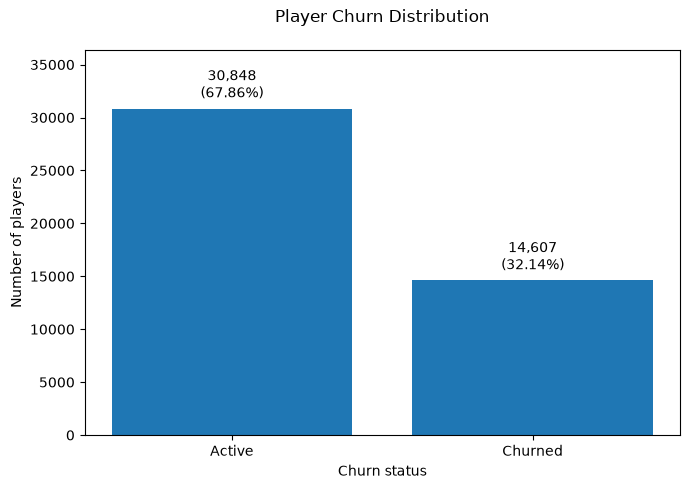

In [69]:
churn_counts = df["churn_status"].value_counts().reset_index()
churn_counts.columns = ["churn_status", "players"]

churn_counts["pct_players"] = (
    churn_counts["players"] / churn_counts["players"].sum() * 100
).round(2)

fig, ax = plt.subplots(figsize=(7, 5))

ax.bar(
    churn_counts["churn_status"],
    churn_counts["players"]
)

ax.set_title("Player Churn Distribution", pad=20)
ax.set_xlabel("Churn status")
ax.set_ylabel("Number of players")

max_players = churn_counts["players"].max()
ax.set_ylim(0, max_players * 1.18)

for i, row in churn_counts.iterrows():
    ax.text(
        i,
        row["players"] + max_players * 0.02,
        f'{row["players"]:,}\n({row["pct_players"]}%)',
        ha="center",
        va="bottom"
    )

plt.tight_layout()
plt.savefig(FIGURES_PATH / "churn_distribution.png", dpi=300)
plt.show()

Most players are active, but a meaningful share is churned.

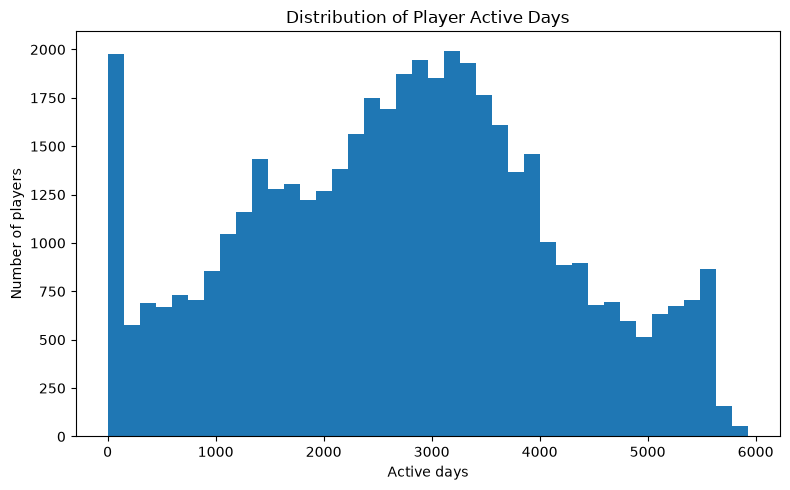

In [51]:
fig,ax = plt.subplots(figsize=(8, 5))

ax.hist(df["active_days"], bins=40)

ax.set_title("Distribution of Player Active Days")
ax.set_xlabel("Active days")
ax.set_ylabel("Number of players")

plt.tight_layout()
plt.savefig(FIGURES_PATH / "active_days_distribution.png", dpi=300)
plt.show()

The distribution of active days shows how long players remain active between their first and last recorded achievement activity.

In [52]:
games_owned_cap = df["games_owned"].quantile(0.99)

df_games_plot = df[df["games_owned"] <= games_owned_cap].copy()

games_owned_cap

np.float64(3214.2999999999956)

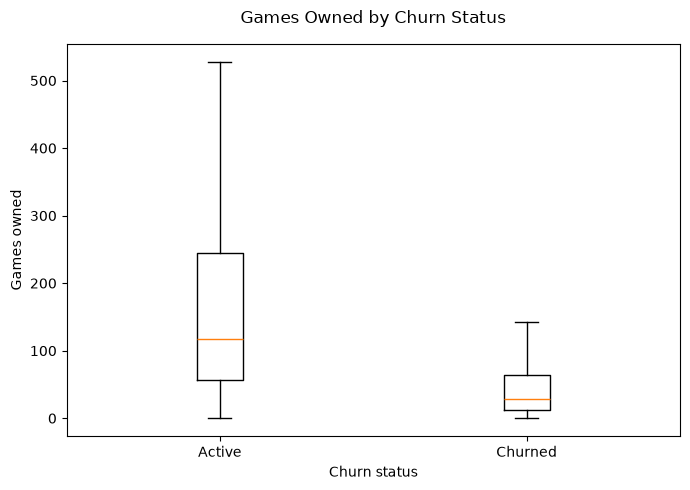

In [61]:
plot_box_by_churn(
    df=df,
    column="games_owned",
    title="Games Owned by Churn Status",
    ylabel="Games owned",
    filename="games_owned_by_churn_status.png"
)

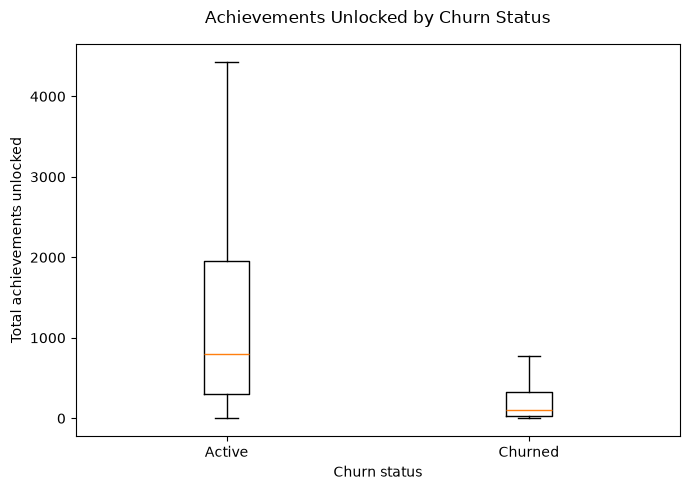

In [64]:
plot_box_by_churn(
    df=df,
    column="total_achievements_unlocked",
    title="Achievements Unlocked by Churn Status",
    ylabel="Total achievements unlocked",
    filename="achievements_by_churn_status.png"
)

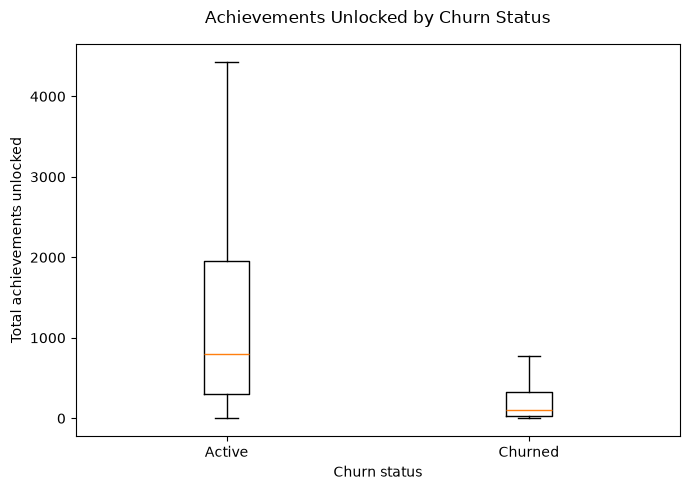

In [65]:
plot_box_by_churn(
    df=df,
    column="total_achievements_unlocked",
    title="Achievements Unlocked by Churn Status",
    ylabel="Total achievements unlocked",
    filename="achievements_by_churn_status.png"
)

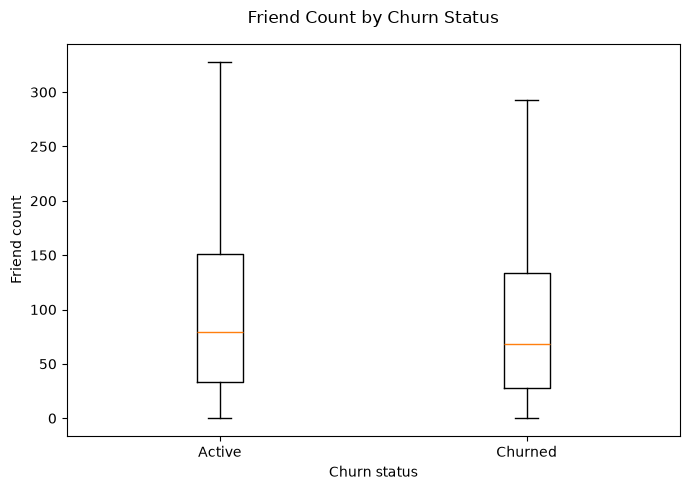

In [66]:
plot_box_by_churn(
    df=df,
    column="friend_count",
    title="Friend Count by Churn Status",
    ylabel="Friend count",
    filename="friend_count_by_churn_status.png"
)

In [70]:
short_activity_summary = pd.DataFrame({
    "metric": [
        "players_with_0_active_days",
        "players_with_7_or_less_active_days",
        "players_with_30_or_less_active_days"
    ],
    "players": [
        (df["active_days"] == 0).sum(),
        (df["active_days"] <= 7).sum(),
        (df["active_days"] <= 30).sum()
    ]
})

short_activity_summary["pct_players"] = (
    short_activity_summary["players"] / len(df) * 100
).round(2)

short_activity_summary

,metric,players,pct_players
0,players_with_0_active_days,1125,2.47
1,players_with_7_or_less_active_days,1317,2.90
2,players_with_30_or_less_active_days,1502,3.30


In [71]:
short_activity_by_churn = (
    df[df["active_days"] <= 30]
    .groupby("churn_status")
    .size()
    .reset_index(name="players")
)

short_activity_by_churn["pct_within_short_activity"] = (
    short_activity_by_churn["players"] /
    short_activity_by_churn["players"].sum() * 100
).round(2)

short_activity_by_churn

,churn_status,players,pct_within_short_activity
0,Active,87,5.79
1,Churned,1415,94.21


## Initial Visual Insights

The churn distribution shows that around one third of players are classified as churned using the 180-day inactivity rule.

Active players generally show stronger engagement patterns than churned players. They tend to own more games, unlock more achievements and remain active for a longer period.

Because the dataset contains extreme high-engagement users, selected charts use capped values or hide outlier points to make typical player behavior easier to compare.

## Short Activity Players

A visible group of players has very short activity duration.
Players with 30 or fewer active days represent 3.30% of the dataset.

Among these short-activity players, 94.21% are classified as churned.
This suggests that early inactivity is strongly associated with churn and may represent one-time or low-engagement users.
